# Book Recommendation System using Collaborative Filtering & Matrix Factorization

This notebook implements:
1. **Item-Based Collaborative Filtering** system to recommend books based on user rating similarity (using Cosine Similarity with KNN).
2. **Matrix Factorization (SVD)** to decompose the sparse rating matrix and generate latent features for books and users.

## 1. Import Libraries

We import the required Python libraries for data processing, sparse representations, nearest neighbors, and Singular Value Decomposition (SVD).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.neighbors import NearestNeighbors
%matplotlib inline
print("Libraries successfully imported!")

Libraries successfully imported!


## 2. Load the Data

We load `Books.csv` and `Ratings.csv` using pandas from the current working directory.

In [2]:
# Load datasets
books = pd.read_csv('Books.csv', low_memory=False)
ratings = pd.read_csv('Ratings.csv', low_memory=False)

# Display dataset shapes and columns
print(f"Books dataset shape: {books.shape}")
print(f"Ratings dataset shape: {ratings.shape}")

Books dataset shape: (7941, 8)
Ratings dataset shape: (111190, 3)


## 3. Data Cleaning and Filtering

To handle matrix sparsity and keep memory usage low, we drop missing values and filter for active users and popular books.

In [3]:
# Drop missing values
books.dropna(inplace=True)
ratings.dropna(inplace=True)

# Filter users who have given at least 50 ratings
user_counts = ratings['User-ID'].value_counts()
ratings = ratings[ratings['User-ID'].isin(user_counts[user_counts >= 50].index)]

# Filter books that have at least 10 ratings
book_counts = ratings['ISBN'].value_counts()
ratings = ratings[ratings['ISBN'].isin(book_counts[book_counts >= 10].index)]

print(f"Filtered Ratings dataset shape: {ratings.shape}")

Filtered Ratings dataset shape: (4917, 3)


# Merge ratings and books
merged_df = pd.merge(ratings, books, on='ISBN')

# Drop duplicates to ensure a clean pivot table
merged_df.drop_duplicates(['User-ID', 'Book-Title'], inplace=True)

# Create the user-item rating matrix
pivot_matrix = merged_df.pivot(index='Book-Title', columns='User-ID', values='Book-Rating').fillna(0)

print(f"Rating Matrix shape (Books x Users): {pivot_matrix.shape}")

# Visualize rating matrix sparsity using a heatmap graph
plt.figure(figsize=(10, 6))
sample_matrix = pivot_matrix.iloc[:100, :100]
sns.heatmap(sample_matrix, cmap='Blues', cbar=True, yticklabels=False, xticklabels=False)
plt.title('Sparsity Heatmap of the Rating Matrix (Subset)')
plt.xlabel('Users (User-ID)')
plt.ylabel('Books (Book-Title)')
plt.show()

In [4]:
# Merge ratings and books
merged_df = pd.merge(ratings, books, on='ISBN')

# Drop duplicates to ensure a clean pivot table
merged_df.drop_duplicates(['User-ID', 'Book-Title'], inplace=True)

# Create the user-item rating matrix
pivot_matrix = merged_df.pivot(index='Book-Title', columns='User-ID', values='Book-Rating').fillna(0)

print(f"Rating Matrix shape (Books x Users): {pivot_matrix.shape}")
print("\nPreview of the Rating Matrix (First 5 books and 5 users):")
display(pivot_matrix.iloc[:5, :5])

Rating Matrix shape (Books x Users): (276, 284)

Preview of the Rating Matrix (First 5 books and 5 users):


User-ID,243,254,507,626,638
Book-Title,,,,,
1984,0.0,9.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,0.0,0.0,0.0,0.0
A Beautiful Mind: The Life of Mathematical Genius and Nobel Laureate John Nash,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,0.0,0.0,0.0


## 5. Model 1: Item-Based Collaborative Filtering (KNN)

We represent the ratings using a sparse matrix and fit a `NearestNeighbors` model using Cosine distance to calculate book similarity.

In [5]:
# Convert pivot table to a sparse matrix
sparse_features = csr_matrix(pivot_matrix.values)

# Initialize and fit Nearest Neighbors model
knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(sparse_features)
print("KNN Model training complete!")

KNN Model training complete!


## 6. Model 2: Matrix Factorization (SVD)

We decompose the User-Item matrix using **Singular Value Decomposition (SVD)** to extract latent factors. Here, we decompose the rating matrix $R$ into $U$, $\Sigma$, and $V^T$ matrices.

In [6]:
# Convert rating matrix values to float for SVD solver
R = pivot_matrix.values.astype(float)

# Set number of latent factors (k)
k = 12

# Perform Singular Value Decomposition (SVD)
U, sigma, Vt = svds(R, k=k)

# Reconstruct the approximated Rating Matrix
sigma = np.diag(sigma)
reconstructed_R = np.dot(np.dot(U, sigma), Vt)

# Create a dataframe of the reconstructed ratings
cf_preds_df = pd.DataFrame(reconstructed_R, index=pivot_matrix.index, columns=pivot_matrix.columns)

print(f"Matrix Factorization Complete!")
print(f"Latent dimensions U shape (Books x Factors): {U.shape}")
print(f"Latent dimensions Vt shape (Factors x Users): {Vt.shape}")
print("\nPreview of the Reconstructed Matrix (First 5 books and 5 users):")
display(cf_preds_df.iloc[:5, :5])

Matrix Factorization Complete!
Latent dimensions U shape (Books x Factors): (276, 12)
Latent dimensions Vt shape (Factors x Users): (12, 284)

Preview of the Reconstructed Matrix (First 5 books and 5 users):


User-ID,243,254,507,626,638
Book-Title,,,,,
1984,-4.191670e-01,3.698106e+00,2.933274e-01,-1.010978e-15,8.999890e-01
1st to Die: A Novel,-8.046721e-02,4.810607e-01,2.912107e-01,-4.785438e-16,5.772231e-01
2nd Chance,4.998150e-02,-1.401988e-03,-5.770849e-02,5.482285e-16,-1.174636e-01
A Beautiful Mind: The Life of Mathematical Genius and Nobel Laureate John Nash,-5.036977e-16,7.755812e-16,8.310761e-17,-5.182883e-31,-2.029166e-16
A Bend in the Road,1.570721e-01,6.293499e-03,-1.136756e-01,3.535532e-16,1.291902e-01


## 7. Output & Evaluation (Recommendations)

We write a helper function that takes a book title, queries both models, and prints the top 5 book recommendations.

/tmp/ipykernel_2428/494667466.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=knn_similarities, y=knn_books, ax=axes[0], palette='viridis')
/tmp/ipykernel_2428/494667466.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=svd_similarities, y=svd_books, ax=axes[1], palette='magma')


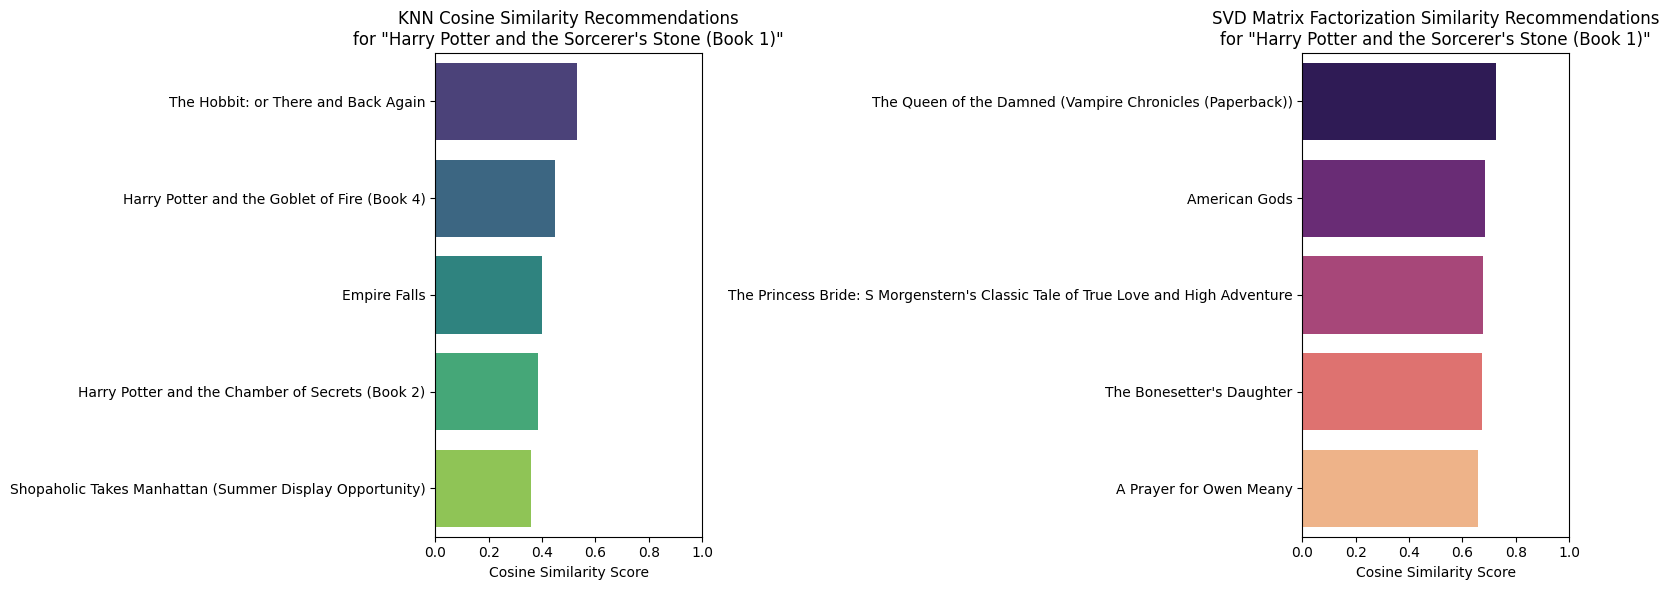

In [7]:
def recommend_books(book_title):
    # Find matching book title
    matching_books = [title for title in pivot_matrix.index if book_title.lower() in title.lower()]
    if not matching_books:
        print(f"Book '{book_title}' not found in the matrix.")
        return

    selected_title = matching_books[0]
    book_idx = pivot_matrix.index.get_loc(selected_title)

    # --- KNN Recommendations ---
    distances, indices = knn_model.kneighbors(
        pivot_matrix.iloc[book_idx, :].values.reshape(1, -1),
        n_neighbors=6
    )

    knn_books = []
    knn_similarities = []
    for i in range(1, len(indices.flatten())):
        knn_books.append(pivot_matrix.index[indices.flatten()[i]])
        # Cosine similarity = 1 - Cosine distance
        knn_similarities.append(1 - distances.flatten()[i])

    # --- SVD Matrix Factorization Recommendations ---
    book_vector = U[book_idx, :].reshape(1, -1)
    norms = np.linalg.norm(U, axis=1, keepdims=True)
    normalized_U = U / np.where(norms == 0, 1e-9, norms)
    normalized_vector = book_vector / np.linalg.norm(book_vector)
    similarities = np.dot(normalized_U, normalized_vector.T).flatten()
    similar_indices = np.argsort(similarities)[::-1]

    svd_books = []
    svd_similarities = []
    count = 1
    for idx in similar_indices:
        if idx == book_idx:
            continue
        svd_books.append(pivot_matrix.index[idx])
        svd_similarities.append(similarities[idx])
        count += 1
        if count > 5:
            break

    # --- Ploting Comparison Graphs ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot KNN
    sns.barplot(x=knn_similarities, y=knn_books, ax=axes[0], palette='viridis')
    axes[0].set_title(f'KNN Cosine Similarity Recommendations\nfor "{selected_title}"')
    axes[0].set_xlabel('Cosine Similarity Score')
    axes[0].set_xlim(0, 1)

    # Plot SVD
    sns.barplot(x=svd_similarities, y=svd_books, ax=axes[1], palette='magma')
    axes[1].set_title(f'SVD Matrix Factorization Similarity Recommendations\nfor "{selected_title}"')
    axes[1].set_xlabel('Cosine Similarity Score')
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

# Example run
recommend_books("Harry Potter and the Sorcerer's Stone")